<a href="https://colab.research.google.com/github/James26-tech/rpi-object-detection/blob/master/SwarmDirective.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics
!pip install supervision
!pip install openvino

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.4/53.4 MB 13.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import geocoder
from ultralytics import YOLO
import openvino

/usr/local/lib/python3.12/dist-packages/geocoder/uscensus.py:36: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('^\d+', self.address, re.UNICODE)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#model_path = '/content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/best.pt'
from google.colab import drive
drive.mount('/content/drive')
#model = YOLO(model_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import supervision as sv
import numpy as np
import os

VIDEO_PATH = "/content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/Walkers.mp4"

# Check if the file exists before attempting to open it
if not os.path.exists(VIDEO_PATH):
    print(f"Error: Video file not found at {VIDEO_PATH}")
    print("Please ensure the file is uploaded to your Google Drive and the path is correct.")
else:
    try:
        video_info = sv.VideoInfo.from_video_path(VIDEO_PATH)
        print(f"Successfully opened video: {video_info}")
    except Exception as e:
        print(f"Error opening video even though file exists: {e}")
        print("This might be due to a corrupted file or an unsupported video format.")

Error: Video file not found at /content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/Walkers.mp4
Please ensure the file is uploaded to your Google Drive and the path is correct.


In [ ]:
model_path = 'best.pt'
# Load the exported OpenVINO model
#ov_model = YOLO('/content/drive/MyDrive/TaskForceSwarm/' + model_path.removesuffix(".pt")+'_openvino_model/', task = "detect")
ov_model = YOLO('/content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/best_openvino_model', task = "detect")
# Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
#model_path =
# Load the exported OpenVINO model
#ov_model = YOLO(model_path.removesuffix(".pt")+'_openvino_model/', task = "detect")
#ov_model = YOLO(model_path.removesuffix(".7z"), task = "detect")
#ov_model = YOLO(model_path, task = "detect")
# Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.

In [ ]:
#ADDED FONT FOR TARGET COUNTER

FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 1.5
FONT_THICKNESS = 3
TEXT_COLOR = (0, 0, 255)  # White text
BG_COLOR = (0, 0, 0)        # Blue background

def process_frame(frame: np.ndarray, _) -> np.ndarray:
    results = model(
        frame,
        imgsz=640,
        device='cuda',
        half=True,
        verbose=False
    )[0]

    detections = sv.Detections.from_ultralytics(results)

    # Draw blue boxes
    frame = box_annotator.annotate(scene=frame, detections=detections)

    # "TARGETS IN SIGHT" counter upper right
    count = len(detections)
    text = f"TARGETS IN SIGHT: {count}"

    (text_w, text_h), _ = cv2.getTextSize(text, FONT, FONT_SCALE, FONT_THICKNESS)
    frame_h, frame_w = frame.shape[:2]
    x = frame_w - text_w - 20
    y = text_h + 20

    cv2.rectangle(frame, (x - 10, y - text_h - 10), (x + text_w + 10, y + 10), BG_COLOR, -1)
    cv2.putText(frame, text, (x, y), FONT, FONT_SCALE, TEXT_COLOR, FONT_THICKNESS)

    return frame


# sv.process_video(source_path=VIDEO_PATH, target_path=f"result.mp4", callback=process_frame)

In [ ]:
#model = YOLO(model_path)

In [ ]:
def detectPerson(im):
  results = ov_model(im, imgsz=800)
  #results = model(im)
  num_detect = int(list(results[0].boxes.cls.cpu().shape)[0])
  conf = results[0].boxes.conf.cpu().numpy().reshape(-1, num_detect).transpose()
  xyxy = results[0].boxes.xyxy.cpu().numpy()
  cls = results[0].boxes.cls.cpu().numpy().reshape(-1, num_detect).transpose()
  output = np.hstack((xyxy, conf, cls))
  return output

In [ ]:
from PIL import Image
im = Image.open("/content/drive/MyDrive/IXEAN SOLUTIONS/Resources/WALKERS.jpg")

In [ ]:
detectPerson(im)


0: 640x640 34 pedestrians, 140.9ms
Speed: 4.4ms preprocess, 140.9ms inference, 49.5ms postprocess per image at shape (1, 3, 640, 640)


(array([[    0.82906],
        [     0.8264],
        [    0.81976],
        [    0.80235],
        [    0.79195],
        [     0.7912],
        [    0.77938],
        [    0.76327],
        [    0.75484],
        [    0.75467],
        [    0.74812],
        [    0.73039],
        [    0.72727],
        [    0.71111],
        [    0.71042],
        [    0.70887],
        [      0.706],
        [    0.69613],
        [    0.66314],
        [    0.58047],
        [    0.56362],
        [     0.5542],
        [     0.4681],
        [    0.45281],
        [    0.44584],
        [    0.41476],
        [    0.40477],
        [    0.38131],
        [    0.36471],
        [    0.34929],
        [    0.32203],
        [    0.31255],
        [    0.30735],
        [     0.2856]], dtype=float32),
 array([[     221.24,      90.568,      251.18,      154.69],
        [     339.76,      177.04,       377.3,      247.83],
        [     31.217,      121.76,      67.802,      186.24],
        [     1

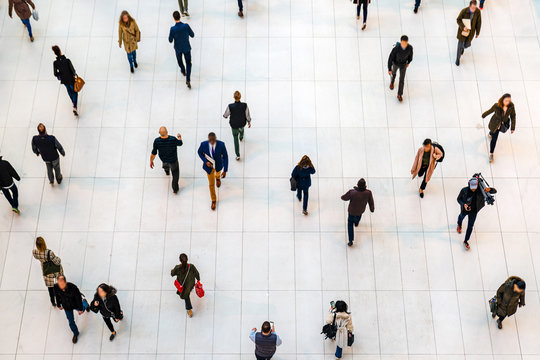

In [ ]:
im

In [ ]:
class Agent:
    def __init__(self, id, start_x, start_y, x_min, x_max):
        self.id = id
        self.current_x = start_x
        self.current_y = start_y
        self.x_min = x_min
        self.x_max = x_max
        self.path = [(start_x, start_y)]

    def zigzag_move(self, y_max, z):
        move_to_max = True
        while self.current_y + z <= y_max:
            if move_to_max:
                self.current_x = self.x_max
            else:
                self.current_x = self.x_min

            self.current_y += z
            self.path.append((self.current_x, self.current_y))
            move_to_max = not move_to_max

        # Ensure the agent reaches the very top
        if self.current_y < y_max:
            self.current_y = y_max
            self.path.append((self.current_x, self.current_y))

def divide_and_assign_agents(x_min, x_max, y_min, y_max, N, Z):
    width = x_max - x_min
    sub_width = width / N
    z = (y_max - y_min) / Z

    agents = []

    for i in range(N):
        x_min_n = x_min + i * sub_width
        x_max_n = x_min + (i + 1) * sub_width if i < N - 1 else x_max
        agent = Agent(i+1, x_min_n, y_min, x_min_n, x_max_n)
        agent.zigzag_move(y_max, z)
        agents.append(agent)
    output = {}
    for agent in agents:
        print(f"Agent {agent.id} Path: {agent.path}")
        output[agent.id] = agent.path
    return output

In [ ]:
def Fitness(frame):
    conf, xyxy, cls = detectPerson(frame)  # ✅ Unpack the tuple

    # ✅ Check using len instead of .size
    if len(xyxy) == 0:
        return [0]
    else:
        fitness_value = xyxy.shape[0]  # Number of detections
        centroids1 = []
        centroids = []

        for row in xyxy:  # ✅ Iterate over bounding boxes
            x_min, x_max = row[0], row[2]
            y_min, y_max = row[1], row[3]
            centroid = ((x_max - x_min) / 2, (y_max - y_min) / 2)
            centroids1.append(centroid[0])
            centroids1.append(centroid[1])
            centroids.append(centroid)

        print(max(centroids1))
        scaler = max(centroids1)
        centroids2 = []

        for centroid in centroids:
            centroid = (centroid[0] / scaler, centroid[1] / scaler)
            centroid = (2 * (centroid[0] - 0.5), 2 * (centroid[1] - 0.5))
            centroids2.append(centroid)

        return [fitness_value] + centroids2

In [ ]:
def get_current_gps():
    # Simulating getting GPS coordinates from the agent's onboard system
    g = geocoder.ip("me")
    return g.latlng

In [ ]:
def SwarmDirective_n(agent_id, frame, gps_agents, paths_agents, fitness_agents, explore_sensitivity, track_sensitivity, swarm_call=None, summon_threshold=5):
    gps_agents[agent_id] = get_current_gps()
    gps_agent = gps_agents[agent_id]
    agent_path = paths_agents[agent_id]
    own_fitness = Fitness(frame)
    fitness_agents[agent_id] = own_fitness[0]
    print(f"Current position of Agent {agent_id} is {gps_agent}")
    if swarm_call is None and own_fitness[0] == 0:
        if gps_agent != agent_path[0]:
            destination = agent_path[0]  # Assume this is the intended path
        else:
            destination = agent_path[1]
            agent_path.pop(0)

    if swarm_call is not None and own_fitness[0] == 0 and swarm_call[1] == agent_id:
        if gps_agent != swarm_call[0]:
            destination = swarm_call[0]
        else:
            destination = agent_path[0]  # Moves to the next point in path

    if own_fitness[0] > 0:
        # Compute a mean path considering all centroids to keep them centered
        centroids = np.array(own_fitness[1:])
        print(f"centroids: {centroids}")
        mean_centroid = np.mean(centroids, axis=0) if centroids.size > 0 else np.array([0, 0])
        print(f"mean direction: {mean_centroid}")
        gps_track = np.array(gps_agent) + track_sensitivity * mean_centroid
        print(f"gps to track targets: {gps_track}")
        new_gps = np.array(explore_sensitivity * np.array(agent_path[0]) + gps_track)
        print(f"destination: {new_gps}")
        destination = new_gps.tolist()

        if own_fitness[0] > summon_threshold:
            # Summon the closest 0 fitness drone
            zero_fitness = {key: value for key, value in fitness_agents.items() if value == 0}
            zero_fitness_gps = {key: gps_agents.get(key, None) for key in zero_fitness}
            gps_differences = {key: np.linalg.norm(np.array(gps_track) - np.array(gps)) for key, gps in zero_fitness_gps.items()}

            # Find the closest agent with 0 fitness
            closest_agent = min(gps_differences, key=gps_differences.get)
            swarm_call = [gps_track.tolist(), closest_agent]

    return destination, gps_agents, fitness_agents, swarm_call


In [ ]:
## Initiatilize arguments ======================
paths_agents = divide_and_assign_agents(x_min = 0, x_max = 30, y_min = 0, y_max = 30, N = 2, Z = 3)
print(paths_agents)

gps_agents = {}
for agent in paths_agents:
    gps_agents[agent] = paths_agents[agent][0]
print(gps_agents)

fitness_agents = {}
for agent in paths_agents:
    fitness_agents[agent] = 0
print(fitness_agents)

Agent 1 Path: [(0.0, 0), (15.0, 10.0), (0.0, 20.0), (15.0, 30.0)]
Agent 2 Path: [(15.0, 0), (30, 10.0), (15.0, 20.0), (30, 30.0)]
{1: [(0.0, 0), (15.0, 10.0), (0.0, 20.0), (15.0, 30.0)], 2: [(15.0, 0), (30, 10.0), (15.0, 20.0), (30, 30.0)]}
{1: (0.0, 0), 2: (15.0, 0)}
{1: 0, 2: 0}


In [ ]:
from ultralytics import YOLO
model = YOLO(
    '/content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/best_openvino_model/',
    task='detect'
)

In [ ]:
SwarmDirective_n(agent_id = 1, frame = im, gps_agents =gps_agents, paths_agents = paths_agents, fitness_agents=fitness_agents, explore_sensitivity = 0, track_sensitivity = 1, swarm_call=None, summon_threshold=5)

Loading /content/drive/MyDrive/IXEAN SOLUTIONS/CV/AI models/best_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

0: 640x640 34 pedestrians, 158.7ms
Speed: 4.9ms preprocess, 158.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
39.663208
Current position of Agent 1 is [41.2619, -95.8608]
centroids: [[    -0.2452     0.61678]
 [  -0.053659     0.78478]
 [  -0.077608     0.62561]
 [   0.025248     0.71541]
 [   -0.37672     0.61038]
 [   -0.44772     0.47857]
 [   -0.12039     0.64587]
 [   -0.10497     0.53528]
 [   -0.13351    0.013392]
 [   0.088323     0.85182]
 [   -0.19601     0.62414]
 [   -0.30713     0.90553]
 [   -0.15561     0.48652]
 [   -0.18922     0.74238]
 [   -0.27065     0.62549]
 [   -0.06812     0.37218]
 [     -0.305     0.56046]
 [  -0.043828     0.37087]
 [  -0.076169     0.68959]
 [    -0.1951    0.079369]
 [    0.17382           1]
 [  -0.056034     0.69442]
 [  -0.044661     0.10871]
 [   -

([41.12782498421669, -95.36270234184265],
 {1: [41.2619, -95.8608], 2: (15.0, 0)},
 {1: 34, 2: 0},
 [[41.12782498421669, -95.36270234184265], 2])